In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

from utils import process_remote, process_insitu, fuse_datasets
from config import no_outlier_check, remote_features, insitu_features1, insitu_features2

Preprocesamiento

In [5]:
# North
remote_df1 = process_remote(
    filepath='../data/processed/satellites/SDH1_S2_20m_2023-10_2026-06.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    interpolation=True,
    stats=True,
    smooth=True,
    window_length=7
)
insitu_df1 = process_insitu(
    filepath='../data/processed/in-situ/SDH1_daily-insitu-data.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    ignore_vars=no_outlier_check,
    interpolation=False,
    smooth=False
)
fused_df1 = fuse_datasets(
    insitu=insitu_df1,
    remote=remote_df1,
    startDate='2024-05-01',
    endDate='2026-07-01',
    features=remote_features+insitu_features1
)
z_df1 = fused_df1.apply(zscore, nan_policy='omit')

# South
remote_df2 = process_remote(
    filepath='../data/processed/satellites/SDH2_S2_20m_2023-10_2026-06.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    interpolation=True,
    stats=True,
    smooth=True,
    window_length=7
)
insitu_df2 = process_insitu(
    filepath='../data/processed/in-situ/SDH2_daily-insitu-data.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    ignore_vars=no_outlier_check,
    interpolation=True,
    smooth=False
)
fused_df2 = fuse_datasets(
    insitu=insitu_df2,
    remote=remote_df2,
    startDate='2024-05-01',
    endDate='2026-07-01',
    features=remote_features+insitu_features2
)
z_df2 = fused_df2.apply(zscore, nan_policy='omit')


/Users/pibonacic/Documents/projects/groundwater-remote-sensing/code/preparation.py:112: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = zscore(df_copy[cols_to_check], nan_policy='omit')


In [3]:
insitu_df1['TEROS12-05cm_water-content_m3m3'].loc['2023':'2024-06-29']

2023-10-06    0.221
2023-10-07    0.221
2023-10-08    0.219
2023-10-09    0.218
2023-10-10    0.217
              ...  
2024-06-25    0.120
2024-06-26    0.118
2024-06-27    0.113
2024-06-28    0.113
2024-06-29    0.119
Freq: D, Name: TEROS12-05cm_water-content_m3m3, Length: 268, dtype: float64

In [8]:
insitu_df1['ATMOS41_precipitation_mm'].loc['2024':'2025']

2024-01-01       NaN
2024-01-02       NaN
2024-01-03       NaN
2024-01-04       NaN
2024-01-05       NaN
               ...  
2025-12-27    13.903
2025-12-28     0.000
2025-12-29     0.000
2025-12-30     0.017
2025-12-31     0.000
Freq: D, Name: ATMOS41_precipitation_mm, Length: 731, dtype: float64

In [ ]:
insitu_df1['ATMOS41_precipitation_mm'].loc['2026-01']

Timestamps
2026-01-01     0.000
2026-01-02     0.000
2026-01-03     0.255
2026-01-04     0.000
2026-01-05     0.000
2026-01-06     0.034
2026-01-07     0.000
2026-01-08     0.000
2026-01-09     0.051
2026-01-10     0.204
2026-01-11     0.034
2026-01-12     0.000
2026-01-13     0.000
2026-01-14     0.068
2026-01-15     1.973
2026-01-16     0.119
2026-01-17     0.000
2026-01-18     0.731
2026-01-19     0.629
2026-01-20     0.953
2026-01-21     5.934
2026-01-22    11.241
2026-01-23     5.445
2026-01-24     0.221
2026-01-25     0.102
2026-01-26     0.136
2026-01-27     0.085
2026-01-28     5.310
2026-01-29     8.190
2026-01-30     2.552
2026-01-31     0.187
Freq: D, Name: ATMOS41_precipitation_mm, dtype: float64

Contenido de agua y temperatura en diferentes profundidades NORTE

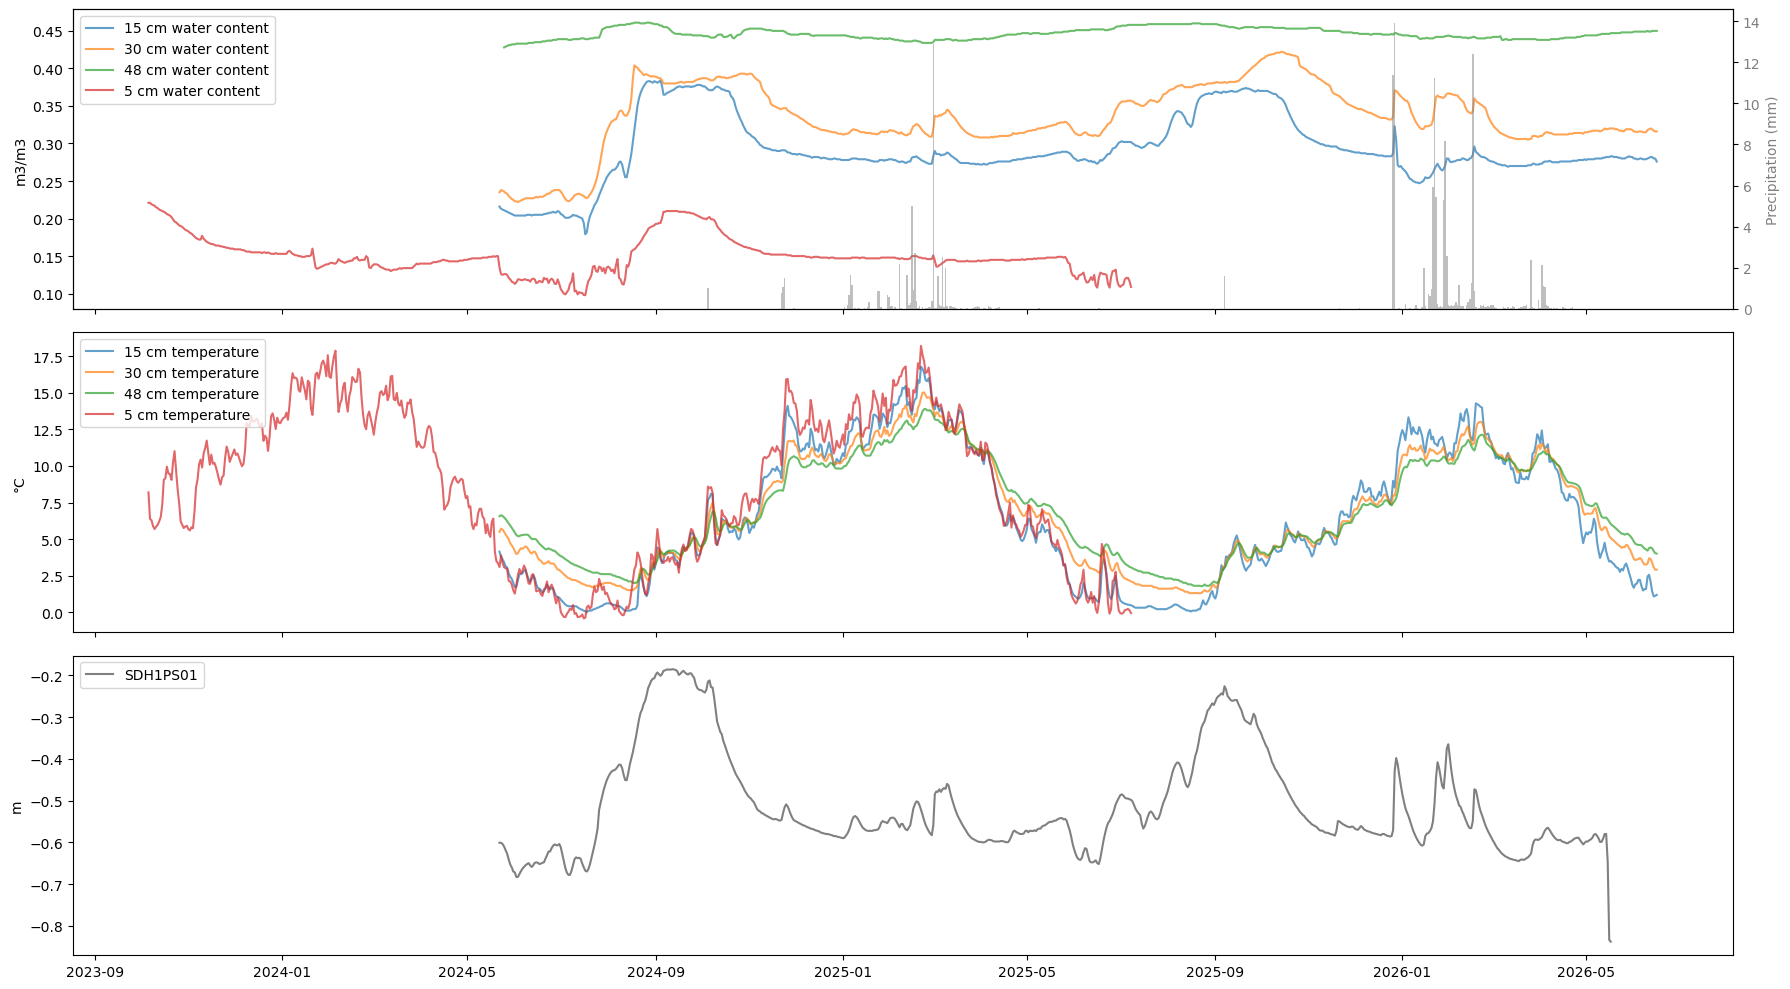

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18,10), sharex=True)

ax1.plot(fused_df1.index, fused_df1['TEROS12-15cm_water-content_m3m3'], label='15 cm water content', alpha=0.7)
ax1.plot(fused_df1.index, fused_df1['TEROS12-30cm_water-content_m3m3'], label='30 cm water content', alpha=0.7)
ax1.plot(fused_df1.index, fused_df1['TEROS12-48cm_water-content_m3m3'], label='48 cm water content', alpha=0.7)
ax1.plot(insitu_df1.index, insitu_df1['TEROS12-05cm_water-content_m3m3'], label='5 cm water content', alpha=0.7)
ax1.set_ylabel('m3/m3')
ax1.legend(loc='upper left')

ax2.plot(fused_df1.index, fused_df1['TEROS12-15cm_soil-temperature_degreeC'], label='15 cm temperature', alpha=0.7)
ax2.plot(fused_df1.index, fused_df1['TEROS12-30cm_soil-temperature_degreeC'], label='30 cm temperature', alpha=0.7)
ax2.plot(fused_df1.index, fused_df1['TEROS12-48cm_soil-temperature_degreeC'], label='48 cm temperature', alpha=0.7)
ax2.plot(insitu_df1.index, insitu_df1['TEROS12-05cm_soil-temperature_degreeC'], label='5 cm temperature', alpha=0.7)
ax2.set_ylabel('°C')
ax2.legend(loc='upper left')

ax3.plot(fused_df1.index, fused_df1['SDH1PS01_gw-depth_m'], label='SDH1PS01', color='gray')
ax3.set_ylabel('m')
ax3.legend(loc='upper left')

ax4 = ax1.twinx()
ax4.bar(fused_df1.index, fused_df1['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax4.set_ylabel('Precipitation (mm)', color='gray')
ax4.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

El efecto de las lluvias se atenúa entre más superficial es la medición ¿significa entonces que el sensor no está midiendo la lluvia infitrada sobre el sensor, sino que el aumento de la humedad por la subida del nivel freático? -> que sube porque infiltra lluvia, pero en el área circundante.

Contenido de agua y temperatura en diferentes profundidades SUR

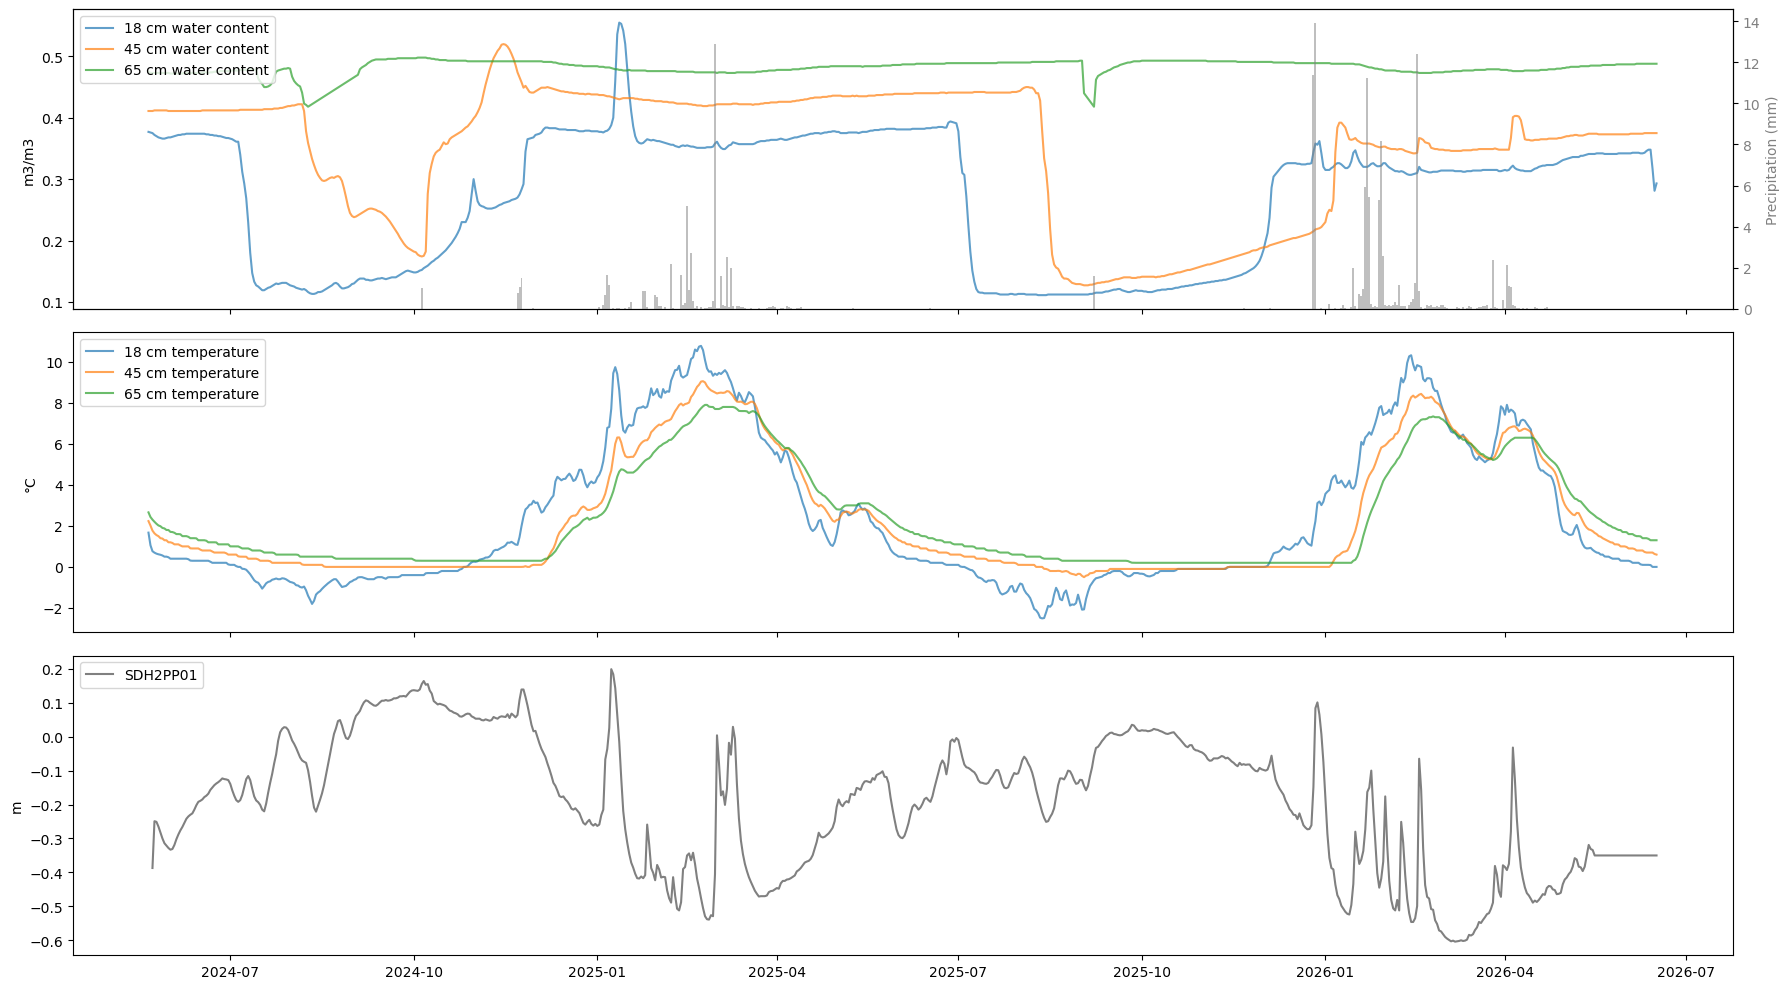

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18,10), sharex=True)

ax1.plot(fused_df2.index, fused_df2['TEROS12-18cm_water-content_m3m3'], label='18 cm water content', alpha=0.7)
ax1.plot(fused_df2.index, fused_df2['TEROS12-45cm_water-content_m3m3'], label='45 cm water content', alpha=0.7)
ax1.plot(fused_df2.index, fused_df2['TEROS12-65cm_water-content_m3m3'], label='65 cm water content', alpha=0.7)
ax1.set_ylabel('m3/m3')
ax1.legend(loc='upper left')

ax2.plot(fused_df2.index, fused_df2['TEROS12-18cm_soil-temperature_degreeC'], label='18 cm temperature', alpha=0.7)
ax2.plot(fused_df2.index, fused_df2['TEROS12-45cm_soil-temperature_degreeC'], label='45 cm temperature', alpha=0.7)
ax2.plot(fused_df2.index, fused_df2['TEROS12-65cm_soil-temperature_degreeC'], label='65 cm temperature', alpha=0.7)
ax2.set_ylabel('°C')
ax2.legend(loc='upper left')

ax3.plot(fused_df2.index, fused_df2['SDH2PP01_gw-depth_m'], label='SDH2PP01', color='gray')
ax3.set_ylabel('m')
ax3.legend(loc='upper left')

ax4 = ax1.twinx()
ax4.bar(fused_df1.index, fused_df1['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax4.set_ylabel('Precipitation (mm)', color='gray')
ax4.tick_params(axis='y', labelcolor='gray')


plt.tight_layout()
plt.show()

Los contenidos de agua se van a pique porque el suelo se congela?

#### Comparación índices

Comparación greenness y WTD NORTE Y SUR

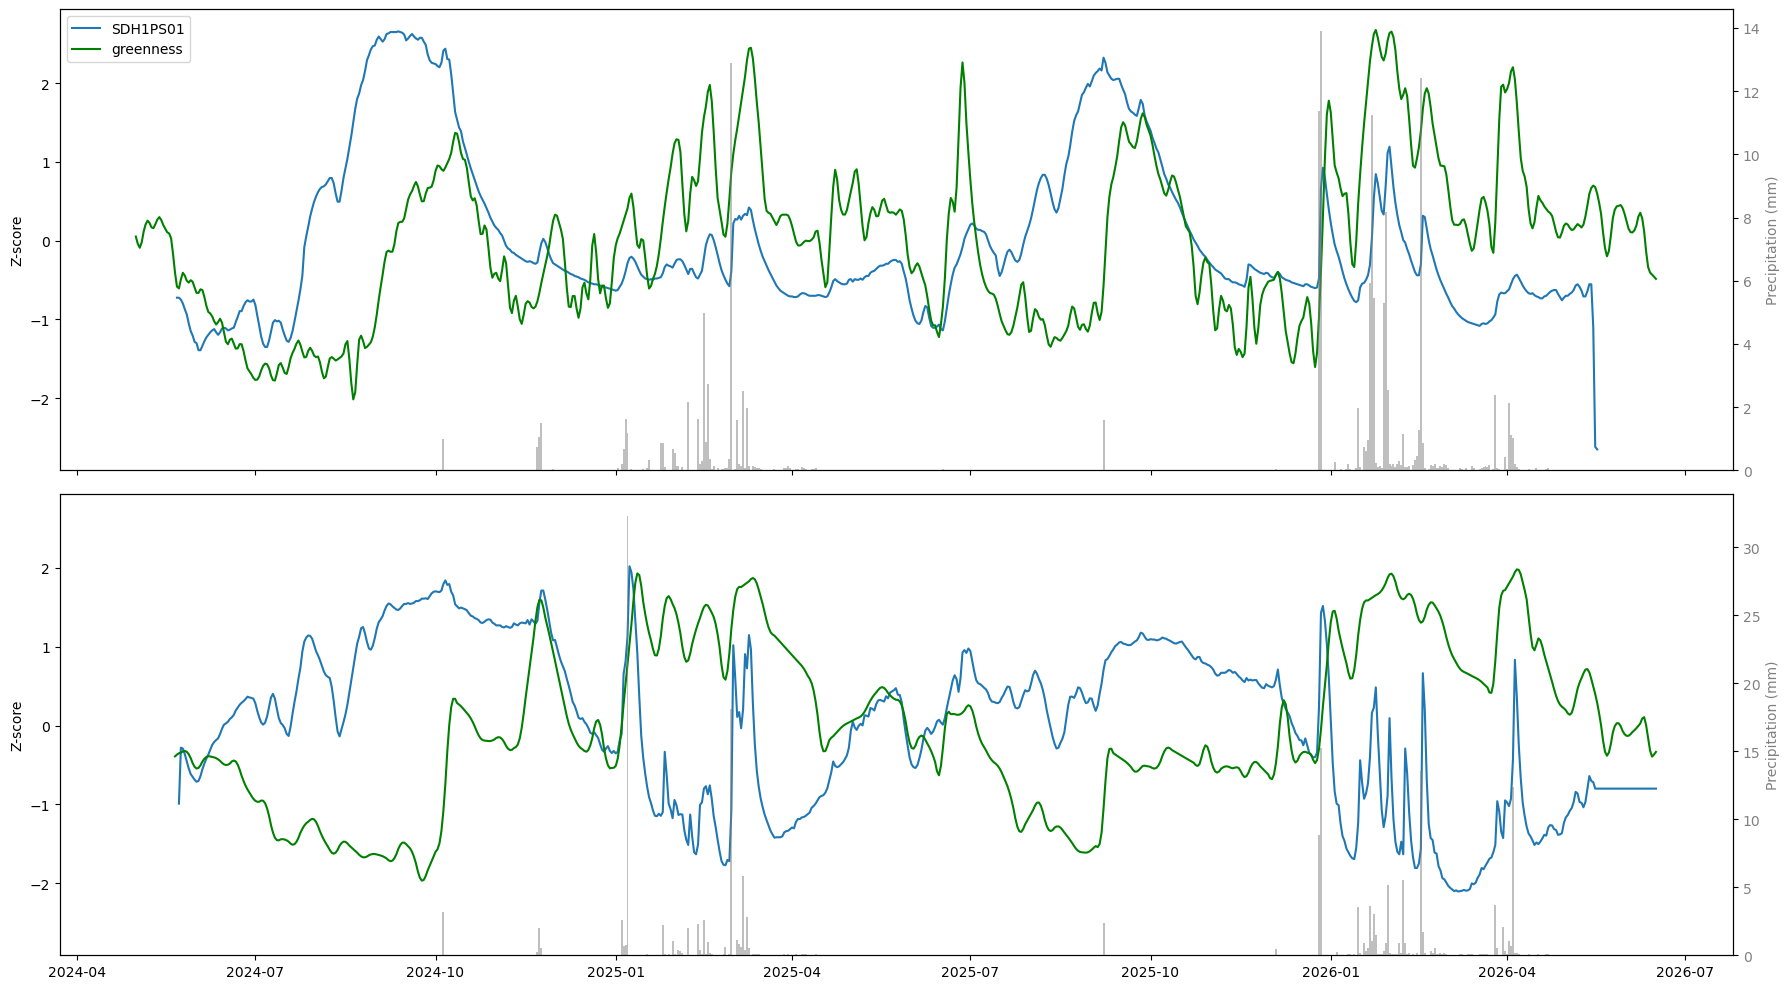

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18,10), sharex=True, sharey=True)

ax1.plot(z_df1.index, z_df1['SDH1PS01_gw-depth_m'], label='SDH1PS01')
ax1.plot(z_df1.index, z_df1['greenness_mean'], label='greenness', color='green')
ax1.set_ylabel('Z-score')

ax3 = ax1.twinx()
ax3.bar(fused_df1.index, fused_df1['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

ax2.plot(z_df2.index, z_df2['SDH2PP01_gw-depth_m'], label='SDH2PP01')
ax2.plot(z_df2.index, z_df2['greenness_mean'], label='greenness', color='green')
ax2.set_ylabel('Z-score')

ax4 = ax2.twinx()
ax4.bar(fused_df2.index, fused_df2['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax4.set_ylabel('Precipitation (mm)', color='gray')
ax4.tick_params(axis='y', labelcolor='gray')

ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

Comparación entre STR 1 y 2 SUR Y NORTE

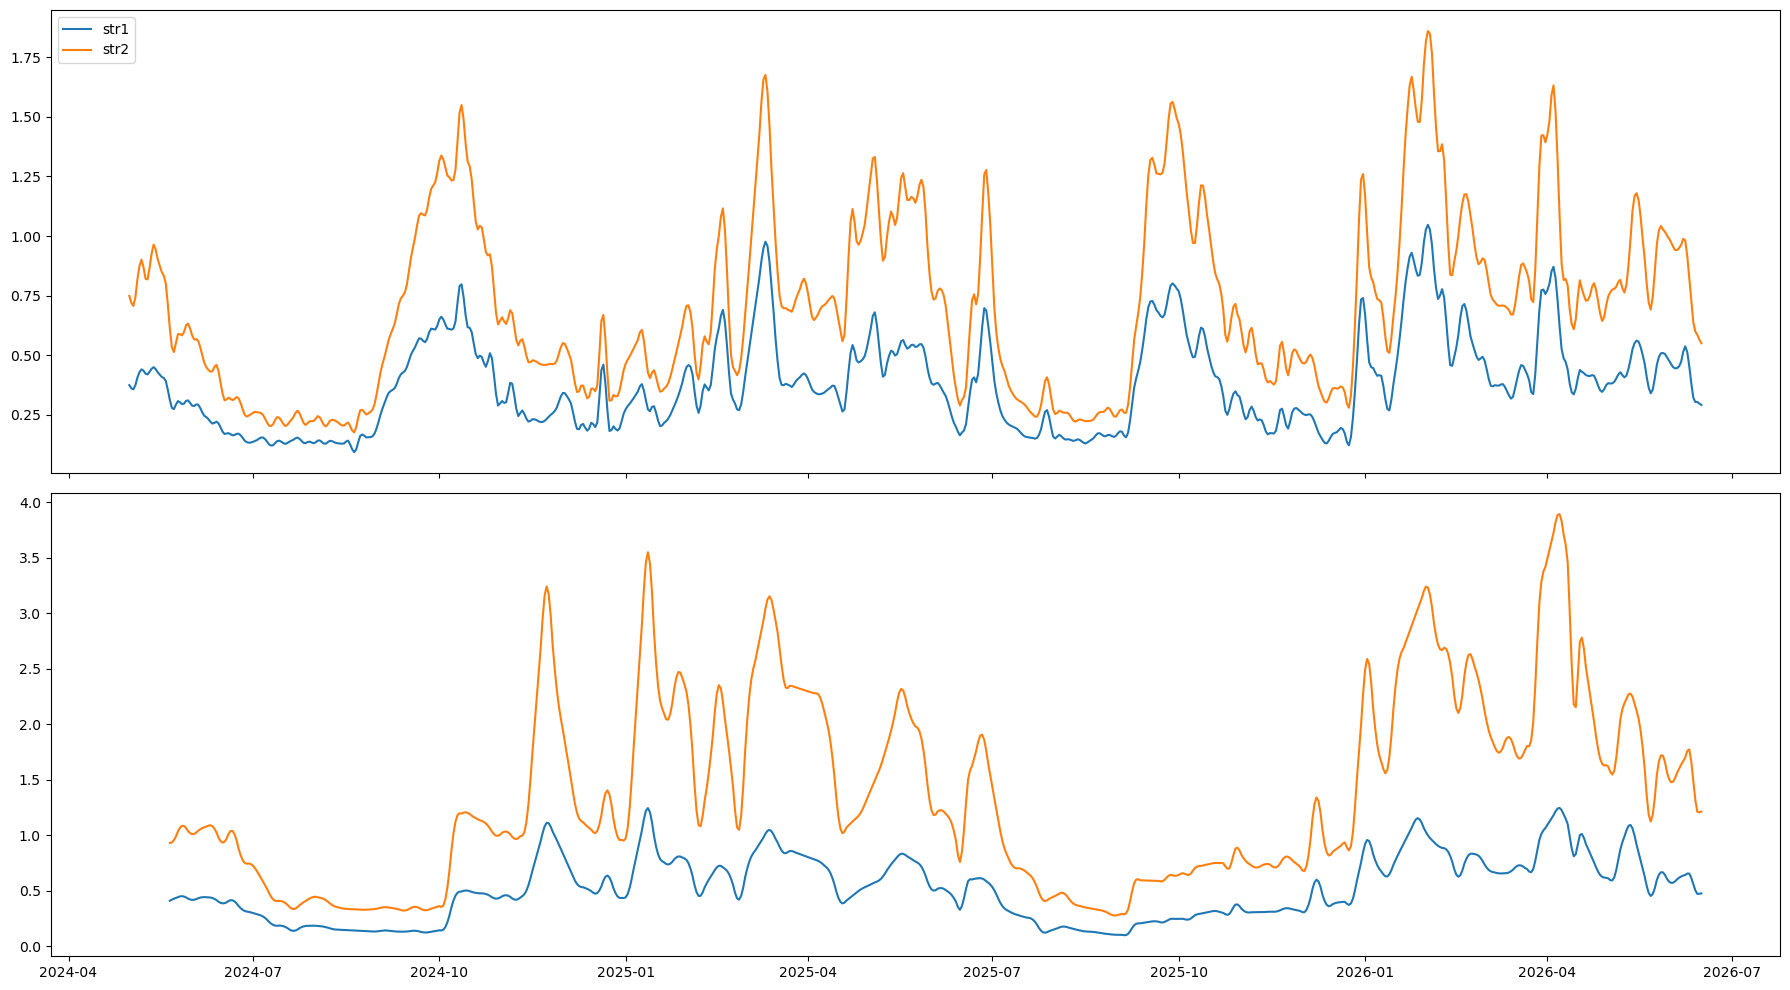

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18,10), sharex=True)

ax1.plot(fused_df1.index, fused_df1['str1_mean'], label='str1')
ax1.plot(fused_df1.index, fused_df1['str2_mean'], label='str2')

ax2.plot(fused_df2.index, fused_df2['str1_mean'], label='str1')
ax2.plot(fused_df2.index, fused_df2['str2_mean'], label='str2')

ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

Comparación STR vs WTD NORTE

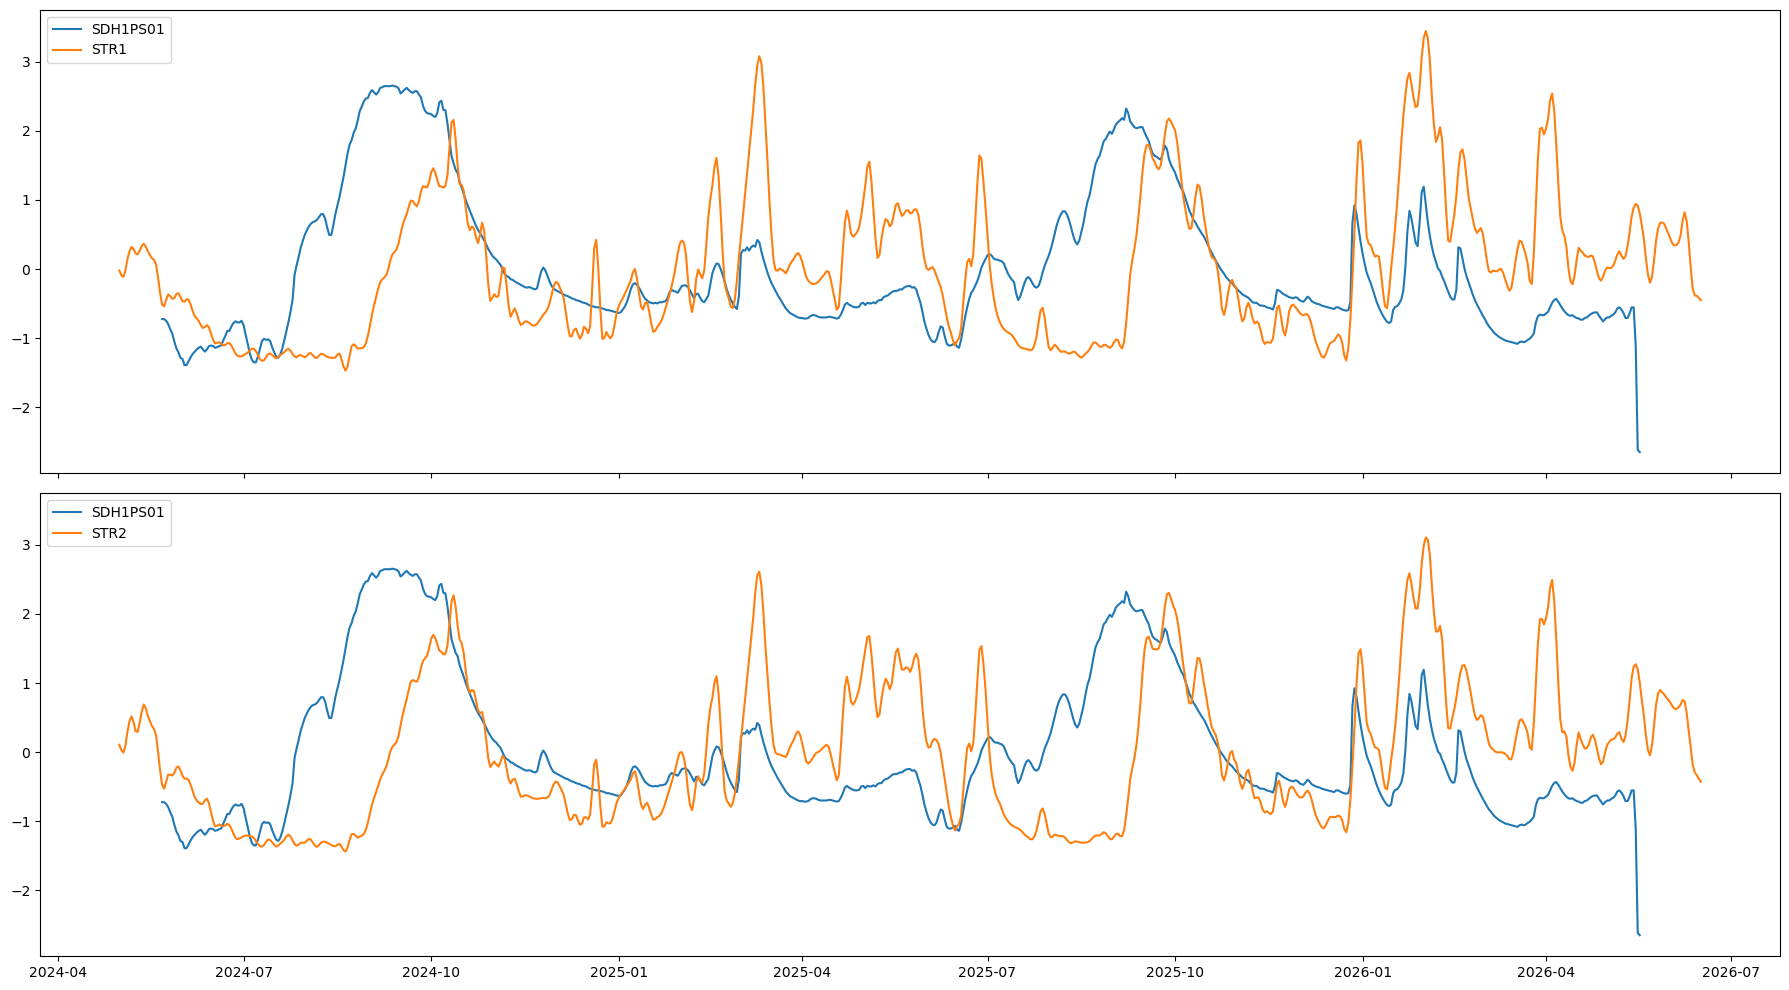

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18,10), sharex=True, sharey=True)

ax1.plot(z_df1.index, z_df1['SDH1PS01_gw-depth_m'], label='SDH1PS01')
ax1.plot(z_df1.index, z_df1['str1_mean'], label='STR1')

ax2.plot(z_df1.index, z_df1['SDH1PS01_gw-depth_m'], label='SDH1PS01')
ax2.plot(z_df1.index, z_df1['str2_mean'], label='STR2')

ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

Comparación STR vs WTD SUR

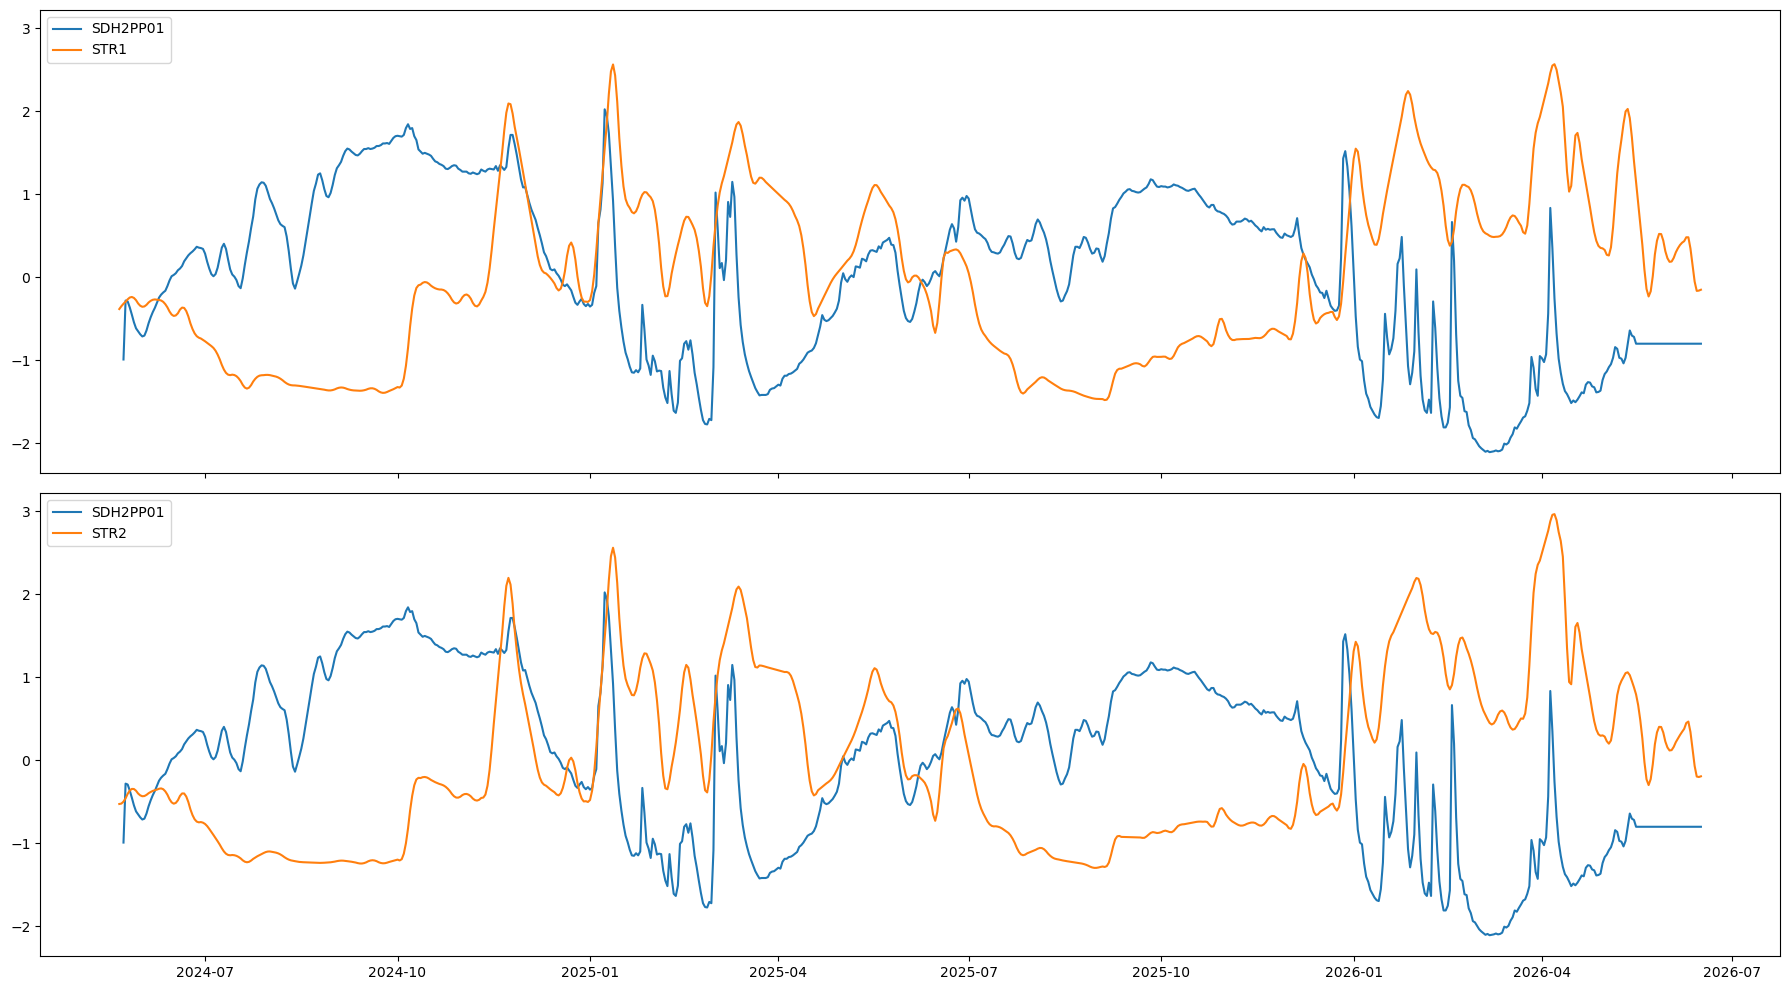

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18,10), sharex=True, sharey=True)

ax1.plot(z_df2.index, z_df2['SDH2PP01_gw-depth_m'], label='SDH2PP01')
ax1.plot(z_df2.index, z_df2['str1_mean'], label='STR1')

ax2.plot(z_df2.index, z_df2['SDH2PP01_gw-depth_m'], label='SDH2PP01')
ax2.plot(z_df2.index, z_df2['str2_mean'], label='STR2')

ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()